In [1]:
import os
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [2]:
import jax
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, SetupKLConfig, SignalSpace, get_builders, image_data, plot_arrays, map_signal

jax.config.update("jax_enable_x64", True)

/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def latest_model_file(directory):
    import os
    import re

    max_file = None
    max_it = -1
    for filename in os.listdir(directory + '/files'):
        match = re.compile(r'(\d+)_pre\.yml$').match(filename)
        if match:
            it = int(match.group(1))
            if it > max_it:
                max_it = it
                max_file = filename

    return directory + f'/files/{max_file}'



def truth_config(data, pre_yml, base_yml):
    import numpy as np
    from aim_resolve import SetupKLConfig, dbscan_clustering, masks_from_maps, model_points, model_objects, model_tiles, yaml_load

    ps_map = data.maps[0]
    oj_map = data.maps[1]
    cl_map, _ = dbscan_clustering(oj_map, eps=0.1, min_samples=3)

    mdl_dct = yaml_load(base_yml).pop('base_model')
    it = 0
    zoom = 1
    tile_size = mdl_dct['tiles']['tile_size']

    cfg = SetupKLConfig.from_file(pre_yml)

    mask_dct = masks_from_maps(ps_map, cl_map, it, zoom, **mdl_dct['masks'], tile_size=tile_size)

    if mdl_dct['points']:
        for pi in filter(lambda x: 'p' in x, mask_dct):
            pi_dct = model_points(mask_dct[pi], ps_map, zoom * data.space, data.val)
            if pi_dct:
                cfg.add_sec(f'sky_{pi}', prefix=pi, **pi_dct)
                cfg.modify_sec(f'sky.{it}', **{pi: f'=sky_{pi}'})

    if mdl_dct['objects']:
        for oi in filter(lambda x: 'o' in x, mask_dct):
            oi_dct = model_objects(mask_dct[oi], zoom * data.space, data.val)
            if oi_dct:
                cfg.add_sec(f'sky_{oi}', prefix=oi, **oi_dct)
                cfg.modify_sec(f'sky.{it}', **{oi: f'=sky_{oi}'})

    if mdl_dct['tiles']:
        for ti in filter(lambda x: 't' in x, mask_dct):
            ti_dct = model_tiles(mask_dct[ti], zoom * data.space, data.val, tile_size)
            if ti_dct:
                cfg.add_sec(f'sky_{ti}', prefix=ti, **ti_dct)
                cfg.modify_sec(f'sky.{it}', **{ti: f'=sky_{ti}'})

    return cfg, ps_map



def box_markers(cfg, ps_map, grid, it):
    import numpy as np
    from aim_resolve import draw_boxes

    px, py = np.argwhere(ps_map == 1).T
    ps_mrk = dict(x=px, y=py, s=10, c='white', marker='+')
    box_map = draw_boxes(cfg.sections, grid, it)
    ox, oy = np.argwhere(box_map == 1).T
    oj_mrk = dict(x=ox, y=oy, s=0.1, c='white', marker=',')
    
    return dict(ps_mrk=ps_mrk, oj_mrk=oj_mrk)

In [13]:
truth_fname = '/Users/rf/Development/packages/aim-resolve/steering/data/runs/files/test512_10.pkl'

exp_dir = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c'
exp_mdl_its = [1, 2, 3]
exp_rec_its = [0, 3]

cmap= 'inferno'

ARCMIN2RAD = np.pi / 60 / 180
AS2RAD = ARCMIN2RAD / 60
CONV_FACTOR = 1000 * AS2RAD**2


exp_yml = latest_model_file(exp_dir)
print('load:', exp_yml)

optim_cfg = OptimizeKLConfig.from_file((exp_dir + '/files/base.yml', exp_yml), get_builders, 'total')

truth = image_data(fname=truth_fname, idx=6)
truth_val = truth.val * CONV_FACTOR
print('ground truth shape:', truth.space.shape)

obs = optim_cfg.instantiate_sec('data.0')
space = SignalSpace.build(shape=truth.space.shape, fov=('2deg','2deg'))
dirty = obs.dirty_image(space)
print('dirty image shape:', dirty.shape)

sky_lst = [sec for sec in optim_cfg.sections if sec.startswith('sky.')]
print('sky components:', sky_lst)

means, stds, markers = [], [], []
for it,sec in enumerate(sky_lst):
    sky_it = optim_cfg.instantiate_sec(sec)
    with open(exp_dir + f'/opt/{it}_rec/last.pkl', "rb") as f:
        smp_it, *_ = pickle.load(f)
    mean, std = smp_it.mean_and_std(sky_it)
    means += [mean * CONV_FACTOR, ]
    stds += [std * CONV_FACTOR, ]

    if it == 0:
        setup_cfg, ps_map = truth_config(truth, exp_dir + '/files/0_pre.yml', exp_dir + '/files/base.yml')
    else:
        setup_cfg = SetupKLConfig.from_file(exp_yml)
        ps_map = np.load(exp_dir + f'/files/{it}_det.npz')['ps_map'].astype(float)
    markers += [box_markers(setup_cfg, ps_map, space, it), ]

load: /Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml
ground truth shape: (512, 512)
dirty image shape: (512, 512)
sky components: ['sky.0', 'sky.1', 'sky.2', 'sky.3', 'sky.4', 'sky.5']
n objects: 28
n noise points: 0


In [ ]:
odir = '/Users/rf/Development/packages/aim-resolve/steering/paper/plots_mJy'
odir = None

plotting ...


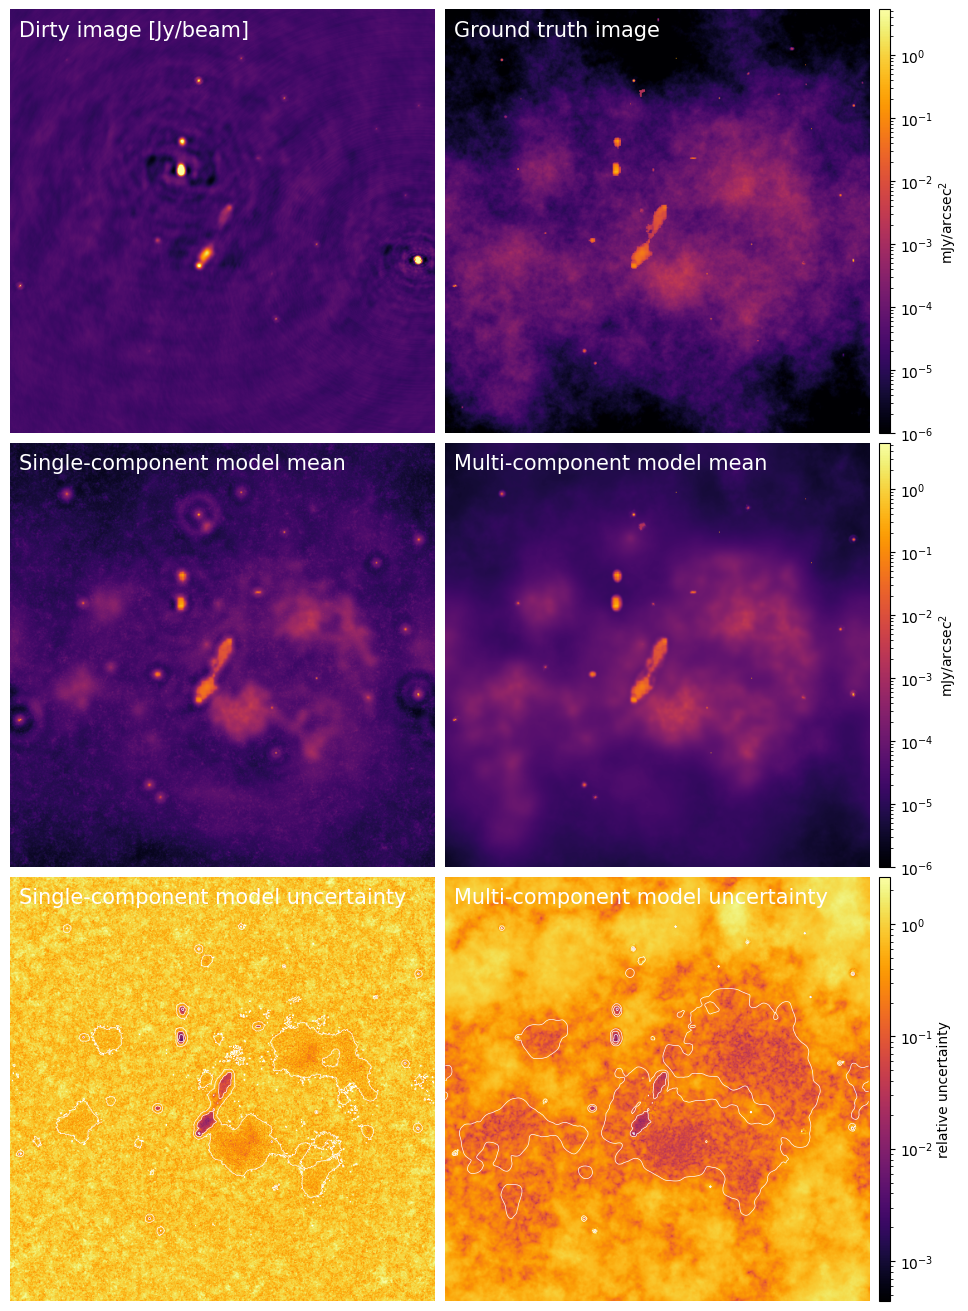

In [36]:
plot_means = [means[i] for i in exp_rec_its]
plot_stds = [stds[i] / means[i] for i in exp_rec_its]

# if 0 in exp_rec_its and os.path.isfile('00_rec/last.pkl'):
#     sky_it = optim_cfg.instantiate_sec('sky.0')
#     with open('00_rec/last.pkl', "rb") as f:
#         smp_it, *_ = pickle.load(f)
#     mean, std = smp_it.mean_and_std(sky_it)
#     idx = exp_rec_its.index(0)
#     plot_means[idx] = mean * CONV_FACTOR
#     plot_stds[idx] = std / mean

plots = [dirty, truth_val] + plot_means + plot_stds

mmin = 1e-6
mmax = max(np.max(arr) for arr in [truth_val,] + plot_means)
smin = min(np.min(arr[arr>0]) for arr in plot_stds)
smax = max(np.max(arr) for arr in plot_stds)
vmin = [None] + 3*[mmin] + 2*[smin]
vmax = [0.054] + 3*[mmax] + 2*[smax]

def callback(fig, axes):
    fig.text(0.045, 0.92, 'Dirty image [Jy/beam]', fontsize=15, c='white')
    fig.text(0.48, 0.92, 'Ground truth image', fontsize=15, c='white')
    fig.text(0.045, 0.631, 'Single-component model mean', fontsize=15, c='white')
    fig.text(0.48, 0.631, 'Multi-component model mean', fontsize=15, c='white')
    fig.text(0.045, 0.342, 'Single-component model uncertainty', fontsize=15, c='white')
    fig.text(0.48, 0.342, 'Multi-component model uncertainty', fontsize=15, c='white')

print('plotting ...')
plot_arrays(
    array=plots, 
    name='exp_recs', 
    odir=odir, 
    norm=['linear'] + 5*['log'], 
    cols=2, 
    vmin=vmin, 
    vmax=vmax, 
    cmap=cmap,
    cbar=[False, True, False, True, False, True],
    cbar_kwargs=
        4*[{'loc': 'right', 'size': '2.5%', 'pad': '2.5%', 'label': 'mJy/arcsec$^2$'}]
        + 2*[{'loc': 'right', 'size': '2.5%', 'pad': '2.5%', 'label': 'relative uncertainty'}],
    contour=
        4*[{}] + [{'array': plots[2], 'colors': 'white', 'levels': [1e-4, 5e-3, 1e-1], 'linewidths': 0.5}]
         + [{'array': plots[3], 'colors': 'white', 'levels': [1e-4, 5e-3, 1e-1], 'linewidths': 0.5}],
    callback=callback,
    ticks=0,
    grid_kwargs=dict(hspace=-0.63, wspace=-0.5, width_ratios=[1,1], height_ratios=[1,1,1]),
    figsize=(5, 5),
    dpi=100,
)

plotting ...


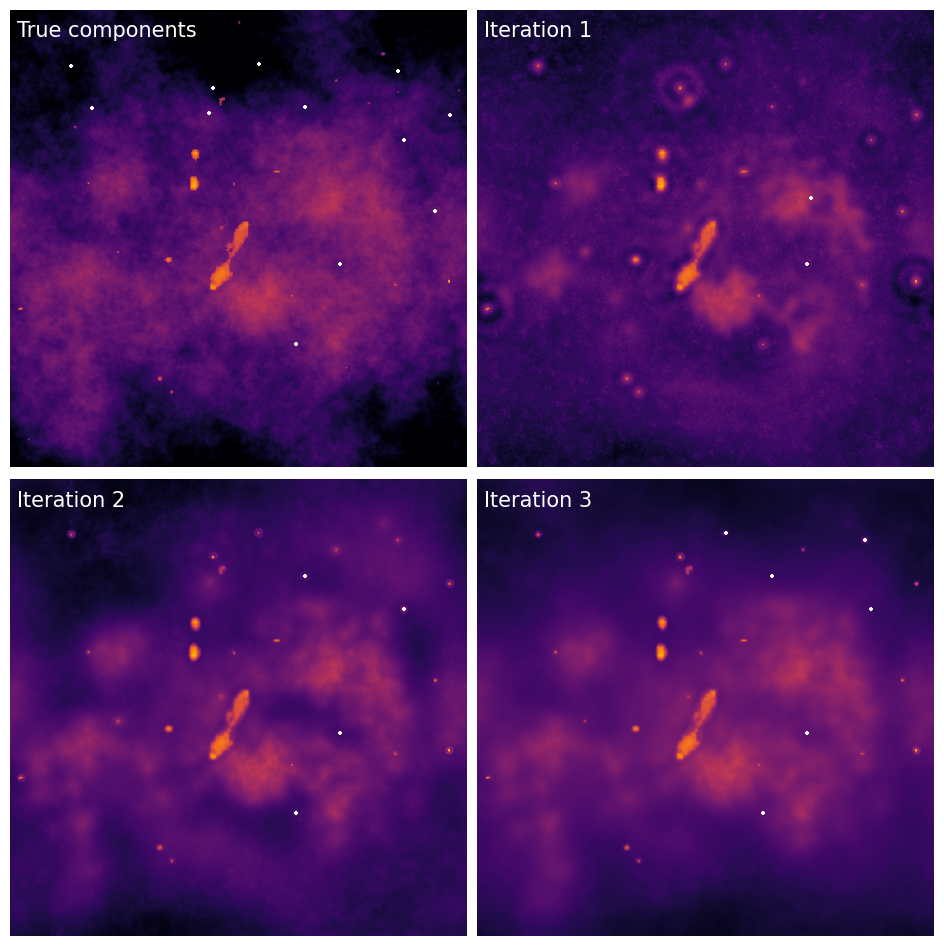

In [45]:
plots = [truth_val, ] + [means[i-1] for i in exp_mdl_its]
markers = [markers[0], ] + [markers[i] for i in exp_mdl_its]

vmin = mmin
vmax = mmax

def callback(fig, axes):
    fig.text(0.045, 0.947, 'True components', fontsize=15, c='white')
    fig.text(0.512, 0.947, 'Iteration 1', fontsize=15, c='white')
    fig.text(0.045, 0.477, 'Iteration 2', fontsize=15, c='white')
    fig.text(0.512, 0.477, 'Iteration 3', fontsize=15, c='white')

print('plotting ...')
plot_arrays(
    plots, 
    name=f'exp_boxes', 
    odir=odir, 
    marker=markers, 
    norm='log', 
    rows=2, 
    cbar=False, 
    vmin=vmin, 
    vmax=vmax,
    callback=callback,
    ticks=0, 
    grid_kwargs=dict(hspace=-0.6, wspace=-0.6, width_ratios=[1,1], height_ratios=[1,1]),
    figsize=(5, 5),
    dpi=100,
)